In [1]:
import sys 
sys.path.append("../")
from LCSS.LCSS_core import *
from DMRG import * 

c:\Users\bik19\anaconda3\envs\GraphState\Lib\site-packages\cotengra\hyperoptimizers\hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(


In [2]:
from copy import copy

def random_ising_model(n):
    init = ["_"] * n
    paulis = []
    for i in range(n-1):
        p = copy(init)
        for idx in range(i,i+2):
            p[idx]  = "X"
        paulis.append("".join(p))
    
    for i in range(n):
        p = copy(init)
        p[i]  = "Z"
        paulis.append("".join(p))
        
    coeffs = np.ones(len(paulis))
        
    return coeffs,paulis

In [3]:
x = [1,5,10,15,20,25,30,35,40,45,50]

In [4]:
from tqdm.notebook import tqdm
n=12

coeffs, paulis = random_ising_model(n)
H = Pauli_Hamiltonian(coeffs, paulis)    
_,groups,phases,_ = get_excited_states(H.convert_to_spare_hamiltonian(),np.max(x))
circs = get_circs(groups,phases,H)

HZ = Pauli_Hamiltonian(coeffs[-n:], paulis[-n:])
states = get_local_excitation_states_parallel(HZ,2,np.max(x))
circsz = [bit_string_to_circ(s[-1]) for s in states]

l = [] 
lz = []
for _ in tqdm(x):
    l.append(H.p_LCSS_opt(circs[:_])[0])
    lz.append(H.p_LCSS_opt(circsz[:_])[0])

g = run_dmrg(convert_to_mpos(paulis,coeffs),20)
l_data  = (abs((g- np.array(l))/g))
lz_data = (abs((g- np.array(lz))/g))



  0%|          | 0/11 [00:00<?, ?it/s]

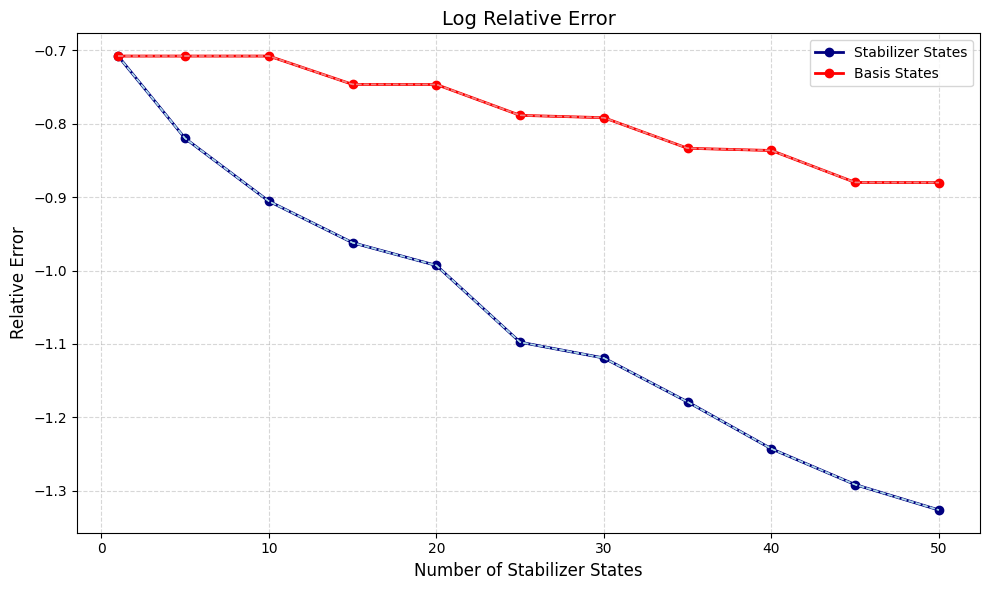

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `x` and `l_data` are already defined

# Compute mean, min, and max
mean_log = np.log10(l_data)
min_log = np.log10(l_data)
max_log = np.log10(l_data)

mean_logz = np.log10(lz_data)
min_logz = np.log10(lz_data)
max_logz = np.log10(lz_data)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, mean_log, '-o',label='Stabilizer States', color='navy', linewidth=2)
plt.fill_between(x, min_log, max_log, color='skyblue', alpha=0.3)
plt.plot(x, min_log, linestyle='--', color='lightblue', linewidth=1)
plt.plot(x, max_log, linestyle='--', color='lightblue', linewidth=1)

plt.plot(x, mean_logz, '-o',label='Basis States', color='red', linewidth=2)
plt.fill_between(x, min_logz, max_logz, color='red', alpha=0.3)
plt.plot(x, min_logz, linestyle='--', color='lightcoral', linewidth=1)
plt.plot(x, max_logz, linestyle='--', color='lightcoral', linewidth=1)


# Style and labels
plt.title('Log Relative Error', fontsize=14)
plt.xlabel('Number of Stabilizer States', fontsize=12)
plt.ylabel('Relative Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [6]:
from tqdm.notebook import tqdm
from qiskit.quantum_info import Operator,SparsePauliOp 

total_error = []
total_errorz = []

error = []
errorz = []
for n in tqdm(range(12,51)):
    coeffs, paulis = random_ising_model(n)
    H = Pauli_Hamiltonian(coeffs, paulis)    
    _,groups,phases,_ = get_excited_states(H.convert_to_spare_hamiltonian(),20)
    circs = get_circs(groups,phases,H)
    
    HZ = Pauli_Hamiltonian(coeffs[-n:], paulis[-n:])
    states = get_local_excitation_states_parallel(HZ,2,20)
    circsz = [bit_string_to_circ(s[-1]) for s in states]
    
    
    energy = (H.p_LCSS_opt(circs)[0])
    energyz = np.linalg.eigvalsh(H.__p_total_elements__(circsz))[0]

    
    g = run_dmrg(convert_to_mpos(paulis,coeffs),30)
    error.append(abs((g- energy)/g))
    errorz.append(abs((g- energyz)/g))
    

  0%|          | 0/39 [00:00<?, ?it/s]

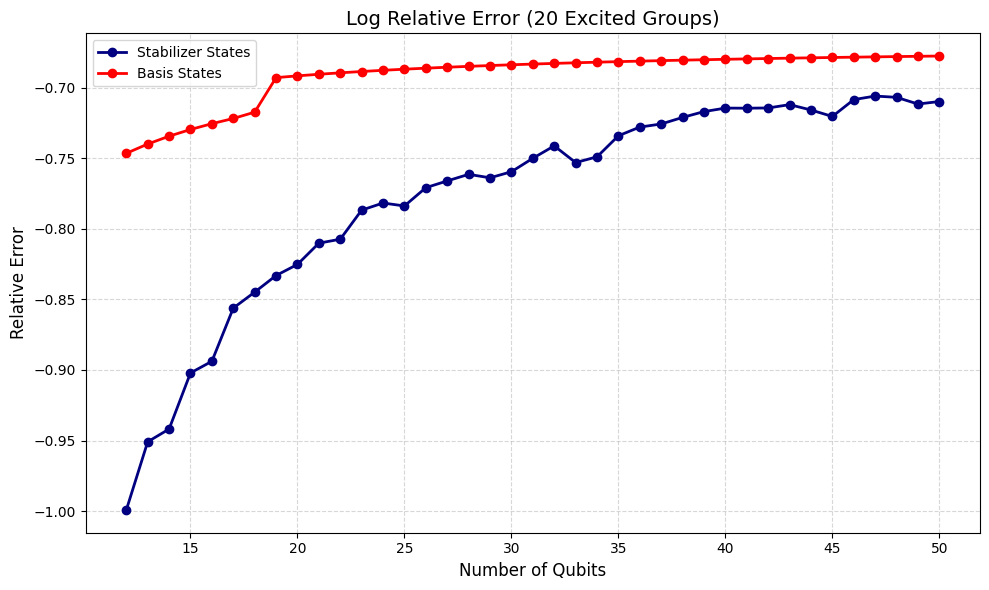

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x=range(12,51)


# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, np.log10(error), '-o',label='Stabilizer States', color='navy', linewidth=2)

plt.plot(x, np.log10(errorz), '-o',label='Basis States', color='red', linewidth=2)



# Style and labels
plt.title('Log Relative Error (20 Excited Groups)', fontsize=14)
plt.xlabel('Number of Qubits', fontsize=12)
plt.ylabel('Relative Error', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()